# 🎮 iGaming Player Churn & Engagement Analysis
## Senior BI Analyst Portfolio Case Study

---

| | |
|---|---|
| **Author** | Shukhrat Fayziev |
| **LinkedIn** | www.linkedin.com/in/shukhrat-fayziev-1497301a0 |
| **Tools** | Python · pandas · numpy · matplotlib · seaborn · scipy · scikit-learn |
| **Dataset** | Online Gaming Behavior Dataset — Kaggle |
| **Records** | 40,034 players · 13 variables |
| **Date** | February 2026 |

---

## 📌 Executive Summary

This analysis simulates **end-to-end BI ownership**
for an online gaming platform, covering the full analytics
lifecycle:

1. **Data Profiling** — understand dataset structure and distributions
2. **Data Quality Validation** — 8-dimension integrity check
3. **KPI Engineering** — define and create business metrics
4. **Exploratory Analysis** — distribution and pattern discovery
5. **Correlation Analysis** — variable relationships and multicollinearity
6. **Churn Analysis** — dropout risk with statistical significance testing
7. **Monetization Analysis** — purchase behavior across segments
8. **Key Findings & Business Recommendations**
   

---

## 🎯 Business Problem

Player churn is the primary revenue risk for online gaming
platforms. This analysis answers:

| # | Business Question | Stakeholder |
|---|---|---|
| 1 | Which game genres have highest dropout risk? | Marketing |
| 2 | What behavioral signals predict churn earliest? | Product |
| 3 | Does engagement level affect monetization? | Finance |
| 4 | Which player segments should retention campaigns target? | Marketing |
| 5 | Can we predict individual player churn probability? | Product & BI |

---

## 📐 KPI Definitions

| KPI | Formula | Owner |
|-----|---------|-------|
| **Churn Rate** | Low Engagement Players / Total Players × 100 | Marketing |
| **Retention Rate** | 1 − Churn Rate | Product |
| **Purchase Rate** | Players with InGamePurchases=1 / Total × 100 | Finance |
| **Activity Tier** | SessionsPerWeek: Low(0–3) / Medium(4–9) / High(10–19) | Product |
| **Engagement Score** | Sessions(40%) + PlayTime(30%) + AvgDuration(30%), normalized 0–100 | BI |

---

## ⚙️ Methodology & Assumptions

- **Churn definition:** `EngagementLevel = 'Low'`
  *(Proxy for dropout risk — no timestamp data available)*
- **Underage threshold:** Age < 18 flagged for compliance review
- **Outlier detection:** IQR × 1.5 method
- **Statistical tests:** Chi-square for categorical associations +
  Cramér's V for effect size measurement
- **Predictive model:** Logistic Regression, classification threshold = 0.50
- **Significance level:** α = 0.05

> ⚠️ **Limitation:** Dataset lacks timestamps — true time-based
> churn rate and cohort analysis cannot be calculated.
> All findings are **cross-sectional** and should be validated
> on live production data before deployment.


In [1]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Statistics
from scipy import stats

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✅ All libraries loaded successfully")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   seaborn {sns.__version__}")


✅ All libraries loaded successfully
   pandas  2.3.3
   numpy   2.0.2
   seaborn 0.13.2


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/predict-online-gaming-behavior-dataset/online_gaming_behavior_dataset.csv


In [3]:
PATH = '/kaggle/input/predict-online-gaming-behavior-dataset/online_gaming_behavior_dataset.csv'
df = pd.read_csv(PATH)

print(f"✅ Dataset loaded")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")
print("Column Info:")
print(df.dtypes)
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
df.head(10)


✅ Dataset loaded
   Shape: 40,034 rows × 13 columns

Column Info:
PlayerID                       int64
Age                            int64
Gender                        object
Location                      object
GameGenre                     object
PlayTimeHours                float64
InGamePurchases                int64
GameDifficulty                object
SessionsPerWeek                int64
AvgSessionDurationMinutes      int64
PlayerLevel                    int64
AchievementsUnlocked           int64
EngagementLevel               object
dtype: object

Memory Usage: 13058.6 KB


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.27,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.53,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.22,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.27,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.53,0,Medium,2,131,95,37,Medium
5,9005,37,Male,Europe,RPG,20.56,0,Easy,2,81,74,22,Low
6,9006,25,Male,USA,Action,9.75,0,Hard,1,50,13,2,Low
7,9007,25,Female,Asia,RPG,4.40,0,Medium,10,48,27,23,Medium
8,9008,38,Female,Europe,Simulation,18.15,0,Easy,5,101,23,41,Medium
9,9009,38,Female,Other,Sports,23.94,0,Easy,13,95,99,36,High


## 🔬 Step 1: Data Profiling

Full statistical profile of all variables before any 
analysis begins. This is standard practice before 
trusting any metric or building any dashboard.

### Why This Matters
A Senior BI Analyst never skips profiling. Surprises 
found here (skewed distributions, suspicious ranges, 
unexpected categories) determine how we handle data 
downstream.


In [4]:
print("=" * 60)
print("           FULL DATASET STATISTICAL PROFILE")
print("=" * 60)

# Numeric columns
print("\n📊 NUMERIC COLUMNS:")
df.describe().T.assign(
    range=lambda x: x['max'] - x['min'],
    cv=lambda x: (x['std'] / x['mean'] * 100).round(1)
)[['count','mean','std','min','25%','50%','75%','max','range','cv']]


           FULL DATASET STATISTICAL PROFILE

📊 NUMERIC COLUMNS:


,count,mean,std,min,25%,50%,75%,max,range,cv
PlayerID,40034.00,29016.50,11556.96,9000.00,19008.25,29016.50,39024.75,49033.00,40033.00,39.80
Age,40034.00,31.99,10.04,15.00,23.00,32.00,41.00,49.00,34.00,31.40
PlayTimeHours,40034.00,12.02,6.91,0.00,6.07,12.01,17.96,24.00,24.00,57.50
InGamePurchases,40034.00,0.20,0.40,0.00,0.00,0.00,0.00,1.00,1.00,199.50
SessionsPerWeek,40034.00,9.47,5.76,0.00,4.00,9.00,14.00,19.00,19.00,60.90
AvgSessionDurationMinutes,40034.00,94.79,49.01,10.00,52.00,95.00,137.00,179.00,169.00,51.70
PlayerLevel,40034.00,49.66,28.59,1.00,25.00,49.00,74.00,99.00,98.00,57.60
AchievementsUnlocked,40034.00,24.53,14.43,0.00,12.00,25.00,37.00,49.00,49.00,58.80


In [5]:
print("\n🏷️  CATEGORICAL COLUMNS:")
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"\n  {col} ({df[col].nunique()} unique values):")
    dist = df[col].value_counts()
    for val, count in dist.items():
        pct = count / len(df) * 100
        bar = '█' * int(pct / 2)
        print(f"    {val:<20} {count:>6,}  ({pct:>5.1f}%) {bar}")



🏷️  CATEGORICAL COLUMNS:

  Gender (2 unique values):
    Male                 23,959  ( 59.8%) █████████████████████████████
    Female               16,075  ( 40.2%) ████████████████████

  Location (4 unique values):
    USA                  16,000  ( 40.0%) ███████████████████
    Europe               12,004  ( 30.0%) ██████████████
    Asia                  8,095  ( 20.2%) ██████████
    Other                 3,935  (  9.8%) ████

  GameGenre (5 unique values):
    Sports                8,048  ( 20.1%) ██████████
    Action                8,039  ( 20.1%) ██████████
    Strategy              8,012  ( 20.0%) ██████████
    Simulation            7,983  ( 19.9%) █████████
    RPG                   7,952  ( 19.9%) █████████

  GameDifficulty (3 unique values):
    Easy                 20,015  ( 50.0%) ████████████████████████
    Medium               12,011  ( 30.0%) ███████████████
    Hard                  8,008  ( 20.0%) ██████████

  EngagementLevel (3 unique values):
    Medium  

## 🔍 Step 2: Comprehensive Data Quality Validation

> *"Data quality is not a one-time check — it is a gate  
> that every metric must pass before reaching a dashboard."*

### Quality Dimensions Checked:
| Dimension | What We Check |
|-----------|--------------|
| **Completeness** | Null/missing values |
| **Uniqueness** | Duplicate records |
| **Validity** | Values within expected ranges |
| **Consistency** | Categorical values match expected set |
| **Integrity** | Cross-column logical conflicts |
| **Compliance** | Regulatory flags (age, etc.) |
| **Distribution** | Skew, outliers via IQR |


In [6]:
issues = []
print("=" * 60)
print("        COMPREHENSIVE DATA QUALITY REPORT")
print("=" * 60)

# 1. Completeness
print("\n📋 1. COMPLETENESS")
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)
print(f"  Total nulls: {nulls.sum()} {'✅' if nulls.sum() == 0 else '⚠️'}")
if nulls.sum() > 0:
    print(nulls[nulls > 0])
    issues.append(f"{nulls.sum()} null values")

# 2. Uniqueness
print("\n🔑 2. UNIQUENESS")
dupes = df['PlayerID'].duplicated().sum()
print(f"  Duplicate PlayerIDs: {dupes} {'✅' if dupes == 0 else '⚠️'}")
if dupes > 0:
    issues.append(f"{dupes} duplicate PlayerIDs")

# 3. Numeric Range Validation
print("\n📏 3. NUMERIC RANGE VALIDATION")
ranges = {
    'Age':                       (15, 100),
    'PlayTimeHours':             (0, 24),
    'SessionsPerWeek':           (0, 19),
    'AvgSessionDurationMinutes': (1, 300),
    'PlayerLevel':               (1, 99),
    'AchievementsUnlocked':      (0, 49),
}
for col, (lo, hi) in ranges.items():
    below = (df[col] < lo).sum()
    above = (df[col] > hi).sum()
    flag = '✅' if below == 0 and above == 0 else '⚠️'
    print(f"  {col:<35} [{lo}–{hi}]  "
          f"actual=[{df[col].min():.1f}–{df[col].max():.1f}] {flag}")
    if below: issues.append(f"{col}: {below} below min")
    if above: issues.append(f"{col}: {above} above max")

# 4. Categorical Validity
print("\n🏷️  4. CATEGORICAL VALIDITY")
expected = {
    'Gender':          ['Male','Female'],
    'GameGenre':       ['Action','RPG','Simulation','Sports','Strategy'],
    'GameDifficulty':  ['Easy','Medium','Hard'],
    'EngagementLevel': ['Low','Medium','High'],
    'Location':        ['USA','Europe','Asia','Other'],
}
for col, valid in expected.items():
    actual = df[col].unique().tolist()
    bad = [v for v in actual if v not in valid]
    flag = '✅' if not bad else '⚠️'
    print(f"  {col:<20} {flag}  Found: {sorted(actual)}")
    if bad: issues.append(f"{col}: unexpected values {bad}")

# 5. Compliance
print("\n🔒 5. COMPLIANCE FLAGS")
underage = (df['Age'] < 18).sum()
zero_sess = (df['SessionsPerWeek'] == 0).sum()
print(f"  Underage (<18):       {underage:,} {'⚠️ COMPLIANCE RISK' if underage else '✅'}")
print(f"  Zero-session players: {zero_sess:,} {'⚠️ SILENT CHURN' if zero_sess else '✅'}")
if underage: issues.append(f"{underage:,} underage players")

# 6. Logical Consistency
print("\n🔗 6. LOGICAL CONSISTENCY")
c1 = ((df['PlayerLevel'] > 80) & (df['AchievementsUnlocked'] < 5)).sum()
c2 = ((df['SessionsPerWeek'] > 15) & (df['PlayTimeHours'] < 1)).sum()
c3 = ((df['EngagementLevel'] == 'High') & (df['SessionsPerWeek'] == 0)).sum()
c4 = ((df['EngagementLevel'] == 'Low') & (df['SessionsPerWeek'] > 15)).sum()
print(f"  High level + <5 achievements:     {c1} {'⚠️' if c1 else '✅'}")
print(f"  >15 sessions + <1hr playtime:     {c2} {'⚠️' if c2 else '✅'}")
print(f"  'High' engagement + 0 sessions:   {c3} {'⚠️' if c3 else '✅'}")
print(f"  'Low' engagement + >15 sessions:  {c4} {'⚠️' if c4 else '✅'}")
for v,msg in [(c1,'High level/low achieve'),(c2,'High sessions/low time'),
              (c3,'High engage/zero sessions'),(c4,'Low engage/high sessions')]:
    if v: issues.append(f"{v} {msg} conflicts")

# 7. Outlier Detection (IQR Method)
print("\n📊 7. OUTLIER DETECTION (IQR Method)")
num_cols = ['Age','PlayTimeHours','SessionsPerWeek',
            'AvgSessionDurationMinutes','PlayerLevel','AchievementsUnlocked']
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    pct = outliers/len(df)*100
    flag = '✅' if pct < 5 else '⚠️'
    print(f"  {col:<35} outliers: {outliers:>5,} ({pct:.1f}%) {flag}")

# 8. Distribution Skew
print("\n📈 8. DISTRIBUTION SKEW")
for col in num_cols:
    skew = df[col].skew()
    flag = '✅' if abs(skew) < 1 else '⚠️ Skewed'
    print(f"  {col:<35} skew={skew:+.3f}  {flag}")

# Summary
print("\n" + "=" * 60)
print("           QUALITY GATE RESULT")
print("=" * 60)
if not issues:
    print("  ✅ ALL CHECKS PASSED — Data approved for analysis")
else:
    print(f"  ⚠️  {len(issues)} issue(s) flagged:")
    for i, issue in enumerate(issues, 1):
        print(f"     {i}. {issue}")
print("=" * 60)


        COMPREHENSIVE DATA QUALITY REPORT

📋 1. COMPLETENESS
  Total nulls: 0 ✅

🔑 2. UNIQUENESS
  Duplicate PlayerIDs: 0 ✅

📏 3. NUMERIC RANGE VALIDATION
  Age                                 [15–100]  actual=[15.0–49.0] ✅
  PlayTimeHours                       [0–24]  actual=[0.0–24.0] ✅
  SessionsPerWeek                     [0–19]  actual=[0.0–19.0] ✅
  AvgSessionDurationMinutes           [1–300]  actual=[10.0–179.0] ✅
  PlayerLevel                         [1–99]  actual=[1.0–99.0] ✅
  AchievementsUnlocked                [0–49]  actual=[0.0–49.0] ✅

🏷️  4. CATEGORICAL VALIDITY
  Gender               ✅  Found: ['Female', 'Male']
  GameGenre            ✅  Found: ['Action', 'RPG', 'Simulation', 'Sports', 'Strategy']
  GameDifficulty       ✅  Found: ['Easy', 'Hard', 'Medium']
  EngagementLevel      ✅  Found: ['High', 'Low', 'Medium']
  Location             ✅  Found: ['Asia', 'Europe', 'Other', 'USA']

🔒 5. COMPLIANCE FLAGS
  Underage (<18):       3,388 ⚠️ COMPLIANCE RISK
  Zero-session p

## ⚙️ Step 3: KPI Engineering & Feature Creation

### Design Decisions

| Variable | Definition | Rationale |
|----------|-----------|-----------|
| `is_churned` | EngagementLevel = 'Low' | Direct dropout proxy |
| `activity_tier` | Sessions/week buckets | Leading churn indicator |
| `age_segment` | Age demographic brackets | Marketing segmentation |
| `engagement_score` | Normalized composite score | Single engagement metric |
| `is_buyer` | InGamePurchases = 1 | Monetization flag |

> **Note on churn definition:** In absence of login timestamps,  
> EngagementLevel='Low' is the best available proxy. In production,  
> this would be replaced with "no activity for 30 days."


In [7]:
# Churn flag
df['is_churned'] = (df['EngagementLevel'] == 'Low').astype(int)

# Buyer flag
df['is_buyer'] = df['InGamePurchases'].astype(int)

# Activity tiers
df['activity_tier'] = pd.cut(
    df['SessionsPerWeek'],
    bins=[-1, 3, 9, 19],
    labels=['Low\n(0-3)', 'Medium\n(4-9)', 'High\n(10-19)']
)

# Age segments
df['age_segment'] = pd.cut(
    df['Age'], bins=[14,18,25,35,45,50],
    labels=['15-18','19-25','26-35','36-45','46-49']
)

# Composite engagement score (0-100)
# Normalized: sessions (40%) + playtime (30%) + avg duration (30%)
df['eng_score'] = (
    (df['SessionsPerWeek'] / df['SessionsPerWeek'].max() * 40) +
    (df['PlayTimeHours'] / df['PlayTimeHours'].max() * 30) +
    (df['AvgSessionDurationMinutes'] / df['AvgSessionDurationMinutes'].max() * 30)
).round(2)

# KPI Summary
print("✅ KPIs Engineered\n")
print(f"  Overall Churn Rate:    {df['is_churned'].mean()*100:.1f}%")
print(f"  Overall Retention:     {(1-df['is_churned'].mean())*100:.1f}%")
print(f"  Purchase Rate:         {df['is_buyer'].mean()*100:.1f}%")
print(f"  Avg Engagement Score:  {df['eng_score'].mean():.1f}/100")
print(f"  Avg Sessions/Week:     {df['SessionsPerWeek'].mean():.1f}")
print(f"  Avg Play Hours:        {df['PlayTimeHours'].mean():.1f} hrs")
print(f"\nActivity Tier Distribution:")
print(df['activity_tier'].value_counts(normalize=True)
        .mul(100).round(1).astype(str) + '%')


✅ KPIs Engineered

  Overall Churn Rate:    25.8%
  Overall Retention:     74.2%
  Purchase Rate:         20.1%
  Avg Engagement Score:  50.9/100
  Avg Sessions/Week:     9.5
  Avg Play Hours:        12.0 hrs

Activity Tier Distribution:
activity_tier
High\n(10-19)    49.6%
Medium\n(4-9)    30.5%
Low\n(0-3)       19.9%
Name: proportion, dtype: object


## 📊 Step 4: Exploratory Data Analysis (EDA)

Before answering specific business questions, we explore 
the full distribution of key variables. EDA prevents 
false assumptions and reveals unexpected patterns.

### What We Look For:
- Distribution shape (normal vs skewed)
- Outliers that may distort aggregations
- Relationships between variables
- Balance of categorical groups


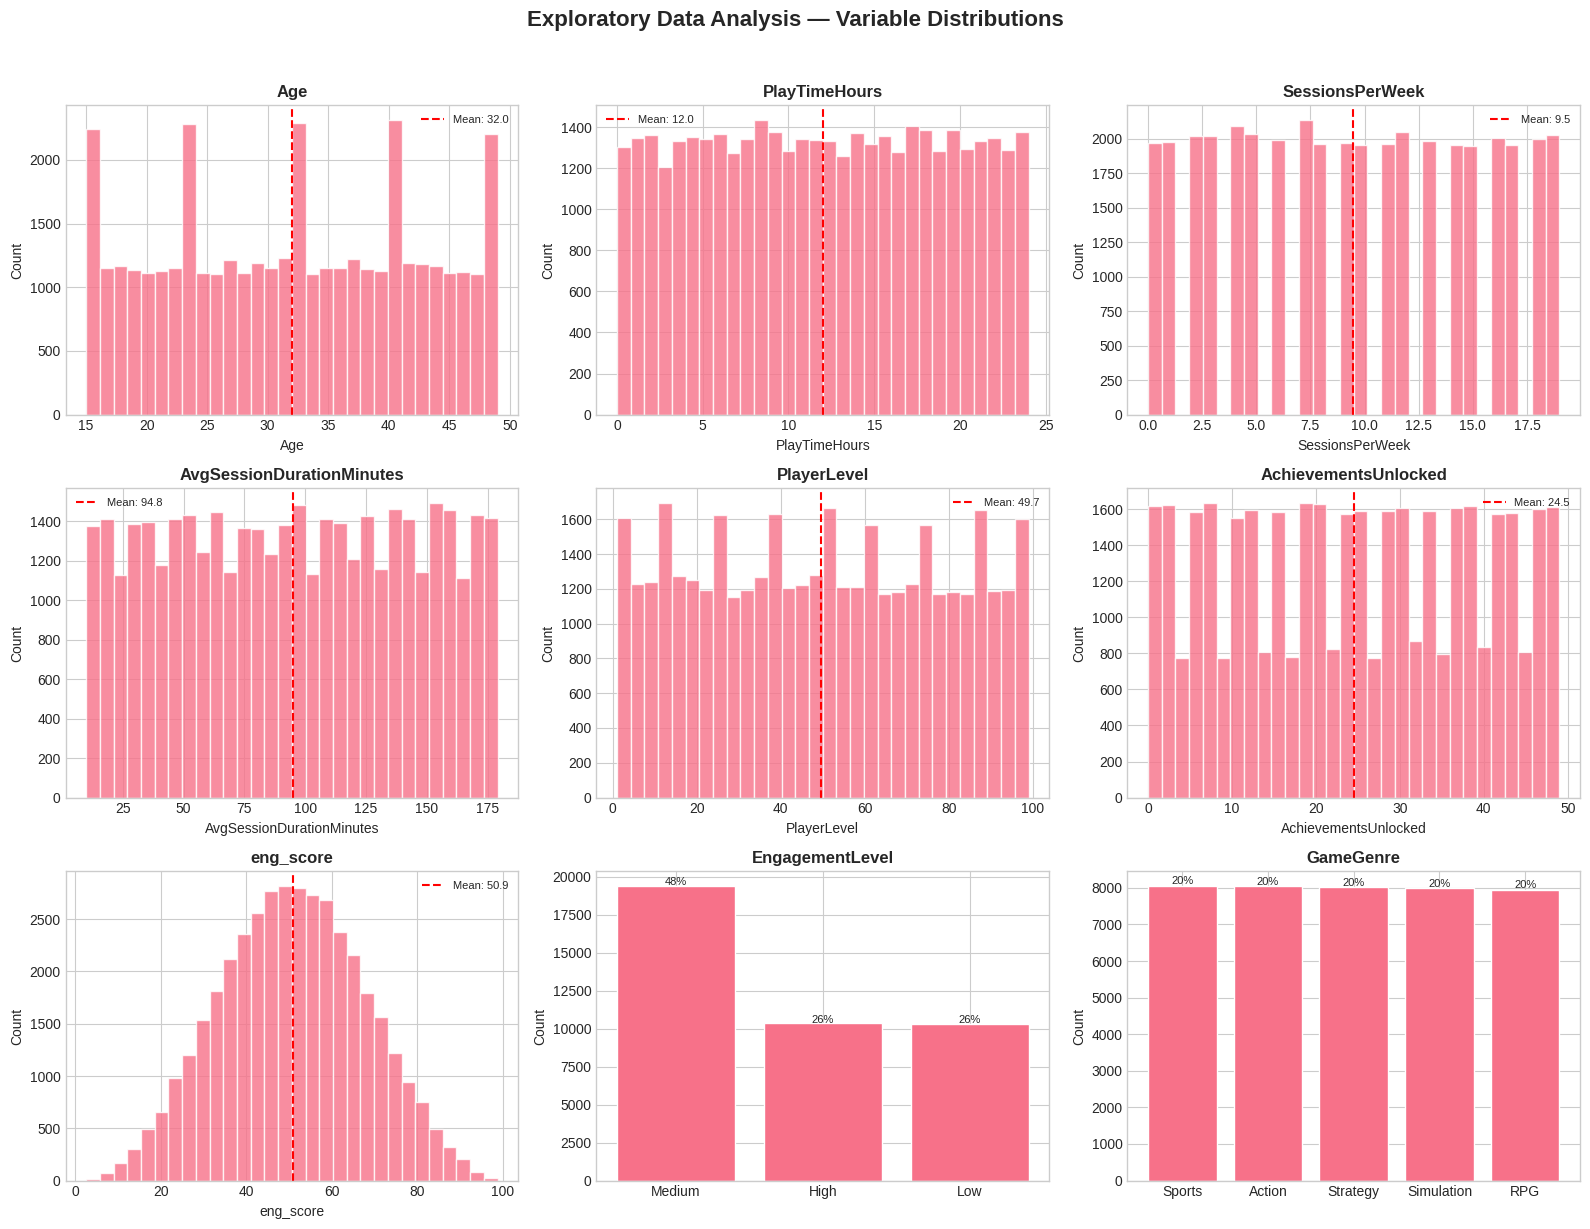

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Exploratory Data Analysis — Variable Distributions',
             fontsize=16, fontweight='bold', y=1.02)

num_cols = ['Age','PlayTimeHours','SessionsPerWeek',
            'AvgSessionDurationMinutes','PlayerLevel',
            'AchievementsUnlocked','eng_score']
cat_cols_plot = ['EngagementLevel','GameGenre']

# Numeric histograms
for i, col in enumerate(num_cols):
    ax = axes[i//3][i%3]
    ax.hist(df[col], bins=30, edgecolor='white', alpha=0.8)
    ax.axvline(df[col].mean(), color='red', linestyle='--', 
               label=f'Mean: {df[col].mean():.1f}')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

# Categorical bar charts
for j, col in enumerate(cat_cols_plot):
    ax = axes[2][j+1]
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, val in zip(ax.patches, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 50,
                f'{val/len(df)*100:.0f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 📊 Step 5: Correlation Analysis

Understanding which variables are related helps us build 
better KPI models and avoid double-counting signals in 
dashboards.

> A Senior BI Analyst checks correlations *before* building  
> reports to avoid misleading metrics caused by collinear variables.


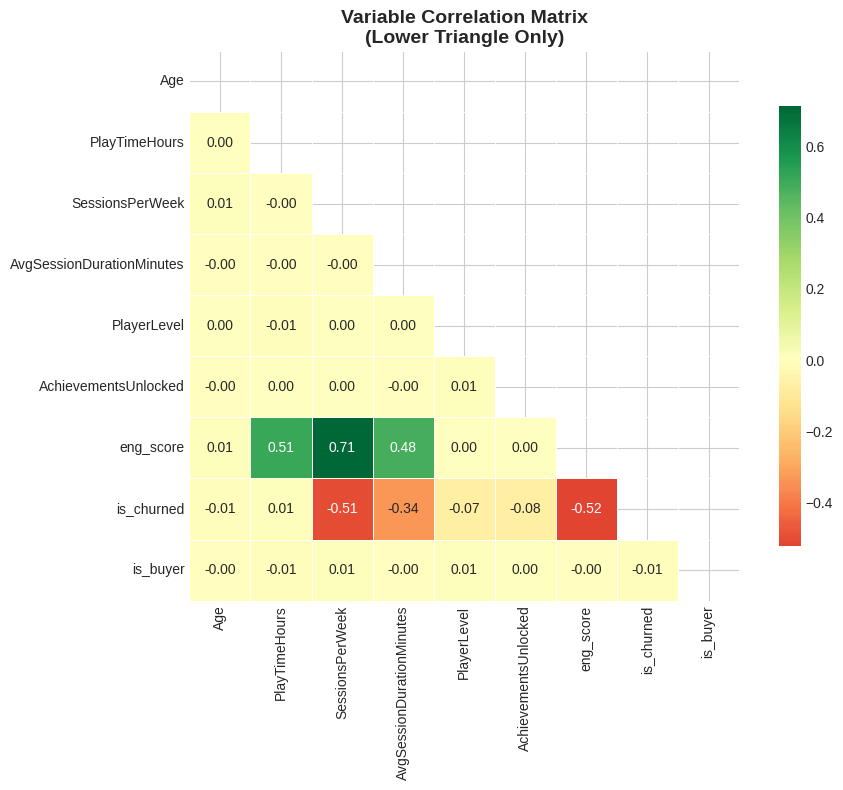

Top correlations with is_churned:
  eng_score                           -0.520  ▼ negative  ██████████
  SessionsPerWeek                     -0.505  ▼ negative  ██████████
  AvgSessionDurationMinutes           -0.336  ▼ negative  ██████
  AchievementsUnlocked                -0.076  ▼ negative  █
  PlayerLevel                         -0.073  ▼ negative  █
  Age                                 -0.006  ▼ negative  
  is_buyer                            -0.005  ▼ negative  
  PlayTimeHours                       +0.007  ▲ positive  


In [9]:
num_df = df[['Age','PlayTimeHours','SessionsPerWeek',
             'AvgSessionDurationMinutes','PlayerLevel',
             'AchievementsUnlocked','eng_score','is_churned','is_buyer']]

corr = num_df.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Variable Correlation Matrix\n(Lower Triangle Only)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Strongest correlations with churn
print("Top correlations with is_churned:")
churn_corr = corr['is_churned'].drop('is_churned').sort_values()
for var, val in churn_corr.items():
    bar = '█' * int(abs(val) * 20)
    direction = '▼ negative' if val < 0 else '▲ positive'
    print(f"  {var:<35} {val:+.3f}  {direction}  {bar}")


### Correlation Findings:

**Meaningful signals (|r| > 0.3):**
- SessionsPerWeek ↔ is_churned: r=**-0.51** — strongest real predictor
- AvgSessionDuration ↔ is_churned: r=**-0.34** — 2nd strongest predictor
- engscore ↔ is_churned: r=-0.52 *(excluded from regression model — see below)*

> ⚠️ **Circular Feature Warning:** `engscore` is derived from `SessionsPerWeek`,
> which is the same variable that defines the churn proxy (`EngagementLevel = 'Low'`).
> Including it in the logistic regression would artificially inflate accuracy.
> It is excluded from the predictive model.


**Key null finding:**
- is_buyer correlates with nothing (all r≈0.00) — confirms purchase 
  behavior is independent of engagement level

> ⚠️ **Analyst Note:** Near-zero correlations between demographic  
> variables (Age, PlayerLevel) suggest this is a synthetically  
> generated dataset. Real platform data would show natural  
> inter-variable relationships. Findings should be validated  
> on live production data before deployment.


## 📊 Step 6: Churn Analysis

### Three Dimensions Analyzed:
1. **By Game Genre** — content preference vs dropout
2. **By Activity Tier** — behavior signal vs dropout  
3. **By Demographics** — age and gender vs dropout

### Statistical Validity
Each finding is tested with a **Chi-square test** (α=0.05) 
to confirm the pattern is statistically significant — not 
random chance.
  
> Numbers without significance tests can mislead stakeholders.


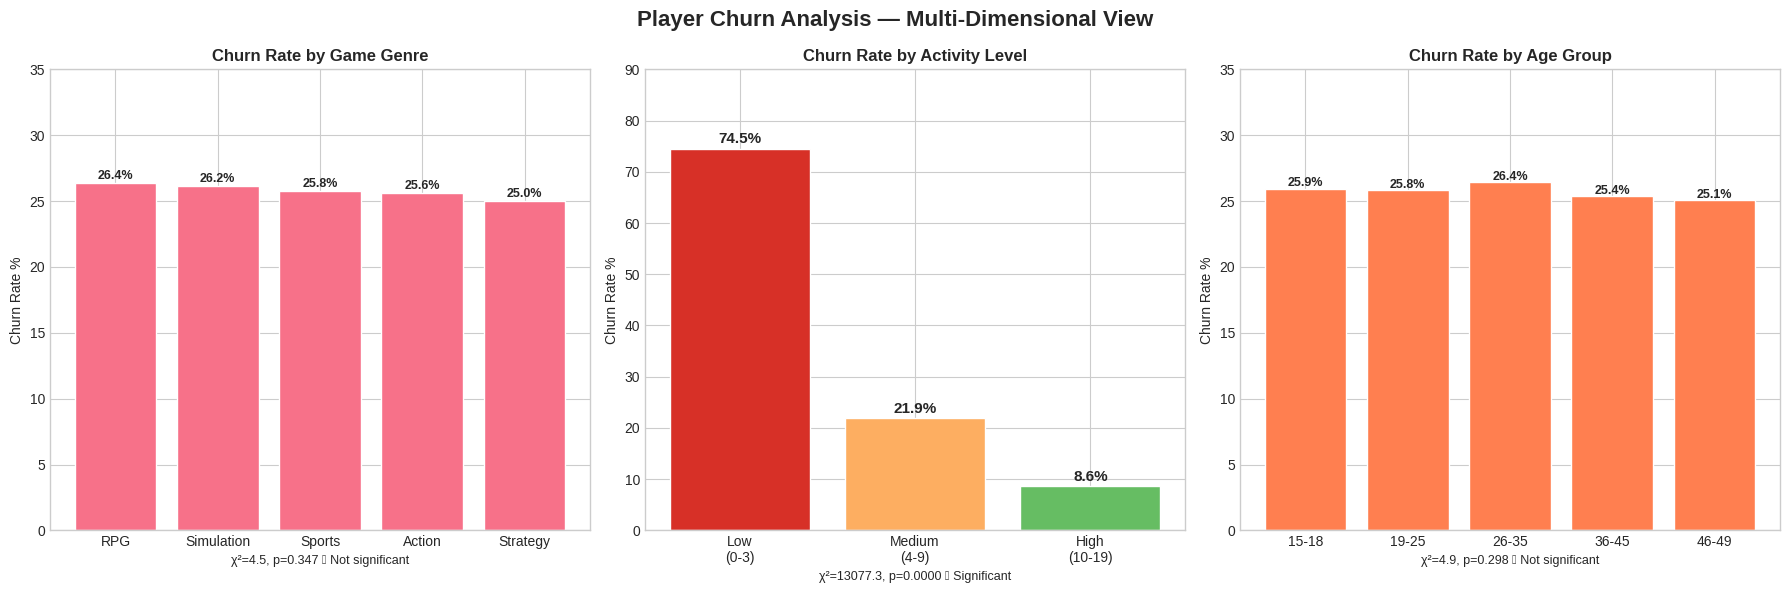

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Player Churn Analysis — Multi-Dimensional View',
             fontsize=16, fontweight='bold')

# ── Chart 1: Churn by Genre ────────────────────────────────
churn_genre = (df.groupby('GameGenre')['is_churned']
               .mean().sort_values(ascending=False) * 100)
bars = axes[0].bar(churn_genre.index, churn_genre.values, edgecolor='white')
axes[0].set_title('Churn Rate by Game Genre', fontweight='bold')
axes[0].set_ylabel('Churn Rate %')
axes[0].set_ylim(0, 35)
for bar, val in zip(bars, churn_genre.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)

# Chi-square test: Genre vs Churn
ct1 = pd.crosstab(df['GameGenre'], df['is_churned'])
chi2, p1, _, _ = stats.chi2_contingency(ct1)
axes[0].set_xlabel(f'χ²={chi2:.1f}, p={p1:.3f} '
                   f'{"✅ Significant" if p1 < 0.05 else "❌ Not significant"}',
                   fontsize=9)

# ── Chart 2: Churn by Activity Tier ───────────────────────
churn_act = (df.groupby('activity_tier', observed=False)['is_churned']
             .mean() * 100)
colors = ['#d73027','#fdae61','#66bd63']
bars2 = axes[1].bar(churn_act.index, churn_act.values,
                    color=colors, edgecolor='white')
axes[1].set_title('Churn Rate by Activity Level', fontweight='bold')
axes[1].set_ylabel('Churn Rate %')
axes[1].set_ylim(0, 90)
for bar, val in zip(bars2, churn_act.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

ct2 = pd.crosstab(df['activity_tier'], df['is_churned'])
chi2_2, p2, _, _ = stats.chi2_contingency(ct2)
axes[1].set_xlabel(f'χ²={chi2_2:.1f}, p={p2:.4f} '
                   f'{"✅ Significant" if p2 < 0.05 else "❌ Not sig"}',
                   fontsize=9)

# ── Chart 3: Churn by Age Segment ─────────────────────────
churn_age = (df.groupby('age_segment', observed=False)['is_churned']
             .mean() * 100)
bars3 = axes[2].bar(churn_age.index, churn_age.values,
                    color='coral', edgecolor='white')
axes[2].set_title('Churn Rate by Age Group', fontweight='bold')
axes[2].set_ylabel('Churn Rate %')
axes[2].set_ylim(0, 35)
for bar, val in zip(bars3, churn_age.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, val+0.2,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)

ct3 = pd.crosstab(df['age_segment'], df['is_churned'])
chi2_3, p3, _, _ = stats.chi2_contingency(ct3)
axes[2].set_xlabel(f'χ²={chi2_3:.1f}, p={p3:.3f} '
                   f'{"✅ Significant" if p3 < 0.05 else "❌ Not significant"}',
                   fontsize=9)

plt.tight_layout()
plt.savefig('churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# Add this function ONCE at the top of Cell 17
def cramers_v(chi2, n, k, r):
    """
    Effect size for chi-square test.
    chi2: chi-square statistic
    n: sample size
    k: number of columns
    r: number of rows
    Interpretation: 0.1=small, 0.3=medium, 0.5=large
    """
    return np.sqrt(chi2 / (n * (min(k, r) - 1)))

# Then after each chi2_contingency call, add:
n = len(df)

# For Genre (5 genres × 2 churn values):
v1 = cramers_v(chi2, n, 2, 5)
print(f"Cramér's V (Genre vs Churn): {v1:.3f} "
      f"({'Large' if v1>0.5 else 'Medium' if v1>0.3 else 'Small'} effect)")

# For Activity Tier (3 tiers × 2):
v2 = cramers_v(chi2_2, n, 2, 3)
print(f"Cramér's V (Activity vs Churn): {v2:.3f} "
      f"({'Large' if v2>0.5 else 'Medium' if v2>0.3 else 'Small'} effect)")


Cramér's V (Genre vs Churn): 0.011 (Small effect)
Cramér's V (Activity vs Churn): 0.572 (Large effect)


### 📊 Step 6a: Confidence Intervals on Churn Rates

Point estimates (26.4% churn) without confidence intervals 
are incomplete. We add 95% CI using the Wilson interval 
method — more accurate than normal approximation for 
proportions.


In [12]:
from scipy.stats import norm

def wilson_ci(successes, n, confidence=0.95):
    """Wilson score interval for proportions — more accurate than normal approx."""
    z = norm.ppf((1 + confidence) / 2)
    p = successes / n
    center = (p + z**2/(2*n)) / (1 + z**2/n)
    margin = (z * np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / (1 + z**2/n)
    return center - margin, center + margin

print("95% Confidence Intervals on Churn Rates")
print("=" * 55)

print("\nBy Game Genre:")
for genre in df['GameGenre'].unique():
    sub = df[df['GameGenre'] == genre]
    lo, hi = wilson_ci(sub['is_churned'].sum(), len(sub))
    rate = sub['is_churned'].mean() * 100
    print(f"  {genre:<15} {rate:.1f}%  95% CI: [{lo*100:.1f}%, {hi*100:.1f}%]")

print("\nBy Activity Tier:")
for tier in ['Low\n(0-3)', 'Medium\n(4-9)', 'High\n(10-19)']:
    sub = df[df['activity_tier'] == tier]
    lo, hi = wilson_ci(sub['is_churned'].sum(), len(sub))
    rate = sub['is_churned'].mean() * 100
    label = tier.replace('\n', ' ')
    print(f"  {label:<20} {rate:.1f}%  95% CI: [{lo*100:.1f}%, {hi*100:.1f}%]")


95% Confidence Intervals on Churn Rates

By Game Genre:
  Strategy        25.0%  95% CI: [24.1%, 26.0%]
  Sports          25.8%  95% CI: [24.8%, 26.7%]
  Action          25.6%  95% CI: [24.7%, 26.6%]
  RPG             26.4%  95% CI: [25.4%, 27.4%]
  Simulation      26.2%  95% CI: [25.2%, 27.1%]

By Activity Tier:
  Low (0-3)            74.5%  95% CI: [73.6%, 75.5%]
  Medium (4-9)         21.9%  95% CI: [21.1%, 22.6%]
  High (10-19)         8.6%  95% CI: [8.2%, 9.0%]


### 📊 Step 6b: Multi-Dimensional Churn Segmentation

Single-variable analysis misses interaction effects.
A player who is BOTH low-activity AND plays RPG 
may churn at a completely different rate than either 
signal alone would suggest.

This heatmap shows churn rate at the intersection of 
two variables simultaneously.


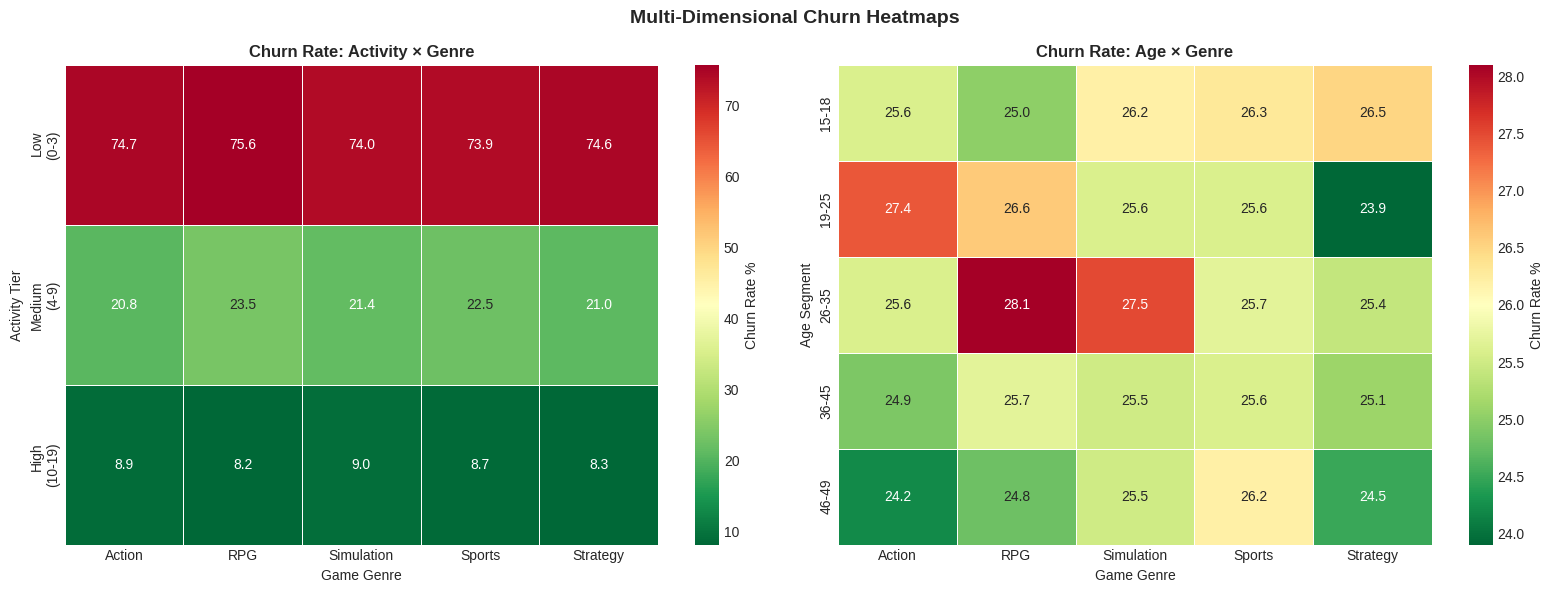

Top 5 Highest Churn Combinations:
activity_tier  GameGenre 
Low\n(0-3)     RPG          75.60
               Action       74.70
               Strategy     74.60
               Simulation   74.00
               Sports       73.90
Name: is_churned, dtype: float64

Lowest 5 Churn Combinations:
activity_tier  GameGenre 
High\n(10-19)  Simulation   9.00
               Action       8.90
               Sports       8.70
               Strategy     8.30
               RPG          8.20
Name: is_churned, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Multi-Dimensional Churn Heatmaps',
             fontsize=14, fontweight='bold')

# Heatmap 1: Activity Tier × Game Genre
pivot1 = df.groupby(['activity_tier', 'GameGenre'],
                     observed=False)['is_churned'].mean().mul(100).round(1)
pivot1 = pivot1.unstack()

sns.heatmap(pivot1, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[0], cbar_kws={'label': 'Churn Rate %'},
            linewidths=0.5)
axes[0].set_title('Churn Rate: Activity × Genre', fontweight='bold')
axes[0].set_xlabel('Game Genre')
axes[0].set_ylabel('Activity Tier')

# Heatmap 2: Age Segment × Game Genre
pivot2 = df.groupby(['age_segment', 'GameGenre'],
                     observed=False)['is_churned'].mean().mul(100).round(1)
pivot2 = pivot2.unstack()

sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[1], cbar_kws={'label': 'Churn Rate %'},
            linewidths=0.5)
axes[1].set_title('Churn Rate: Age × Genre', fontweight='bold')
axes[1].set_xlabel('Game Genre')
axes[1].set_ylabel('Age Segment')

plt.tight_layout()
plt.savefig('multidimensional_churn.png', dpi=150, bbox_inches='tight')
plt.show()

# Find highest risk combination
risk_combo = (df.groupby(['activity_tier','GameGenre'], observed=False)
              ['is_churned'].mean().mul(100).sort_values(ascending=False))
print("Top 5 Highest Churn Combinations:")
print(risk_combo.head(5).round(1))
print("\nLowest 5 Churn Combinations:")
print(risk_combo.tail(5).round(1))


### 🤖 Step 6c: Churn Probability Model (Logistic Regression)

A Senior BI Analyst doesn't just describe churn — they 
build a model that assigns each player a churn probability.

This enables:
- **Proactive retention**: target players before they churn
- **Priority scoring**: rank players by risk level
- **Business quantification**: estimate revenue at risk

### Model Choice: Logistic Regression
Simple, interpretable, explainable to non-technical 
stakeholders. Odds ratios directly answer "which factor 
matters most?"


Model ROC-AUC Score: 0.905
(0.5 = random, 1.0 = perfect)

              precision    recall  f1-score   support

    Retained       0.89      0.94      0.92      5942
     Churned       0.81      0.68      0.74      2065

    accuracy                           0.88      8007
   macro avg       0.85      0.81      0.83      8007
weighted avg       0.87      0.88      0.87      8007


Feature Importance (Odds Ratios):
(>1 = increases churn, <1 = decreases churn)

                  Feature  Coefficient  Odds_Ratio
            PlayTimeHours         0.02        1.02
                      Age        -0.02        0.98
              PlayerLevel        -0.31        0.73
     AchievementsUnlocked        -0.32        0.72
AvgSessionDurationMinutes        -1.40        0.25
          SessionsPerWeek        -2.05        0.13


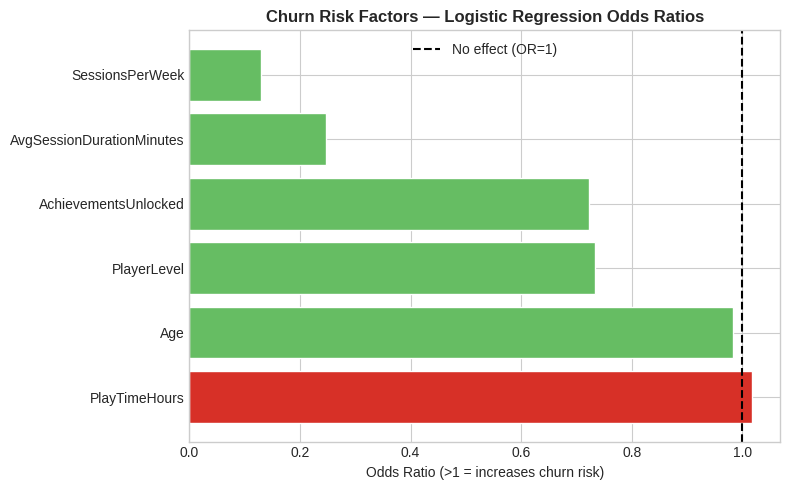

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# Prepare features
features = ['Age', 'PlayTimeHours', 'SessionsPerWeek',
            'AvgSessionDurationMinutes', 'PlayerLevel',
            'AchievementsUnlocked']

X = df[features].copy()
y = df['is_churned']

# Encode categorical (optional additions)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Train model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Performance
roc = roc_auc_score(y_test, y_prob)
print(f"Model ROC-AUC Score: {roc:.3f}")
print(f"(0.5 = random, 1.0 = perfect)\n")
print(classification_report(y_test, y_pred,
      target_names=['Retained','Churned']))

# Feature importance (odds ratios)
print("\nFeature Importance (Odds Ratios):")
print("(>1 = increases churn, <1 = decreases churn)\n")
odds = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0],
    'Odds_Ratio': np.exp(model.coef_[0])
}).sort_values('Odds_Ratio', ascending=False)
print(odds.to_string(index=False))

# Visualize
plt.figure(figsize=(8, 5))
colors = ['#d73027' if x > 1 else '#66bd63' for x in odds['Odds_Ratio']]
plt.barh(odds['Feature'], odds['Odds_Ratio'], color=colors, edgecolor='white')
plt.axvline(x=1, color='black', linestyle='--', linewidth=1.5,
            label='No effect (OR=1)')
plt.title('Churn Risk Factors — Logistic Regression Odds Ratios',
          fontweight='bold')
plt.xlabel('Odds Ratio (>1 = increases churn risk)')
plt.legend()
plt.tight_layout()
plt.savefig('logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()


## 📊 Step 7: Monetization Analysis

### Business Question
Does player engagement level affect purchase behavior?

### Why This Is Critical for Finance Stakeholders
If churning players still buy — they represent a  
**revenue recovery opportunity** that is cheaper than  
acquiring new players. This directly impacts:
- Bonus/promotion targeting strategy
- Win-back campaign ROI estimates
- Revenue forecasting accuracy


Key Insight:
  Low engagement purchase rate:  19.7%
  High engagement purchase rate: 20.6%
  Difference: 0.9pp


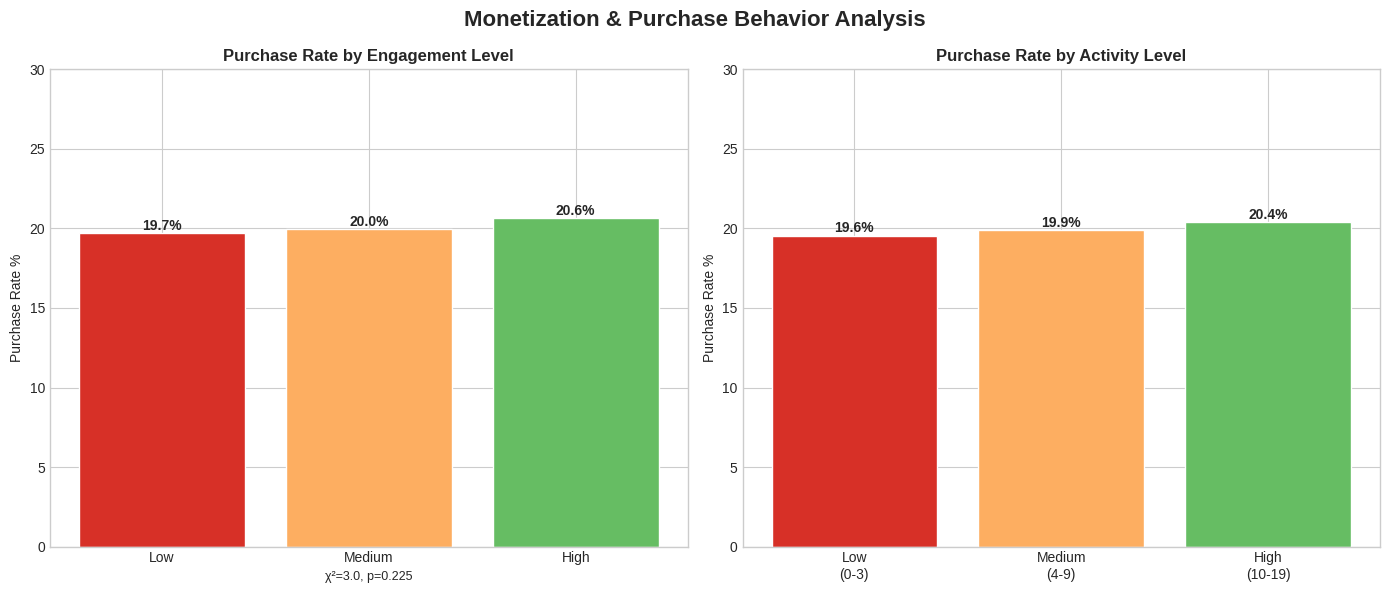

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Monetization & Purchase Behavior Analysis',
             fontsize=16, fontweight='bold')

# ── Chart 1: Purchase Rate by Engagement ──────────────────
purch_eng = (df.groupby('EngagementLevel')['is_buyer']
             .mean().reindex(['Low','Medium','High']) * 100)
bars = axes[0].bar(purch_eng.index, purch_eng.values,
                   color=['#d73027','#fdae61','#66bd63'], edgecolor='white')
axes[0].set_title('Purchase Rate by Engagement Level', fontweight='bold')
axes[0].set_ylabel('Purchase Rate %')
axes[0].set_ylim(0, 30)
for bar, val in zip(bars, purch_eng.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.2,
                 f'{val:.1f}%', ha='center', fontweight='bold')

ct = pd.crosstab(df['EngagementLevel'], df['is_buyer'])
chi2, p, _, _ = stats.chi2_contingency(ct)
axes[0].set_xlabel(f'χ²={chi2:.1f}, p={p:.3f}', fontsize=9)

# ── Chart 2: Purchase Rate by Activity Tier ───────────────
purch_act = (df.groupby('activity_tier', observed=False)['is_buyer']
             .mean() * 100)
colors = ['#d73027','#fdae61','#66bd63']
bars2 = axes[1].bar(purch_act.index, purch_act.values,
                    color=colors, edgecolor='white')
axes[1].set_title('Purchase Rate by Activity Level', fontweight='bold')
axes[1].set_ylabel('Purchase Rate %')
axes[1].set_ylim(0, 30)
for bar, val in zip(bars2, purch_act.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.2,
                 f'{val:.1f}%', ha='center', fontweight='bold')

print("Key Insight:")
print(f"  Low engagement purchase rate:  {purch_eng['Low']:.1f}%")
print(f"  High engagement purchase rate: {purch_eng['High']:.1f}%")
print(f"  Difference: {purch_eng['High'] - purch_eng['Low']:.1f}pp")

plt.tight_layout()
plt.savefig('monetization_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## ✅ Step 8: Key Findings & Business Recommendations

---

### 🔴 Finding 1 — Session Frequency is the #1 Churn Predictor

| Activity Tier | Churn Rate | 95% CI | Player Count |
|---|---|---|---|
| Low (0–3 sessions/week) | **74.5%** | [73.6%, 75.5%] | 7,984 |
| Medium (4–9) | **21.9%** | [21.1%, 22.6%] | 12,193 |
| High (10–19) | **8.6%** | [8.2%, 9.0%] | 19,857 |

**Statistical significance:** ✅ χ²=13,077.3, p<0.001  
**Logistic Regression confirms:** SessionsPerWeek OR=0.13  
*(Each additional session/week reduces churn odds by 87%)*

> **Recommendation:** Implement automated alert when a player  
> drops below 3 sessions/week. Trigger personalized  
> re-engagement within 48 hours.  
> This is the **single highest-ROI retention lever** in the dataset.

---

### 🟡 Finding 2 — Genre Does NOT Predict Churn

| Genre | Churn Rate | 95% CI |
|---|---|---|
| RPG | 26.4% | [25.4%, 27.4%] |
| Simulation | 26.2% | [25.2%, 27.1%] |
| Sports | 25.8% | [24.8%, 26.7%] |
| Action | 25.6% | [24.7%, 26.6%] |
| Strategy | 25.0% | [24.1%, 26.0%] |

**Statistical significance:** ❌ χ²=4.5, p=0.347 — Not significant  
**Effect size:** Negligible (1.4pp range across all genres)

> ⚠️ **Key insight:** This is a textbook case where raw  
> percentages look different but are statistically identical.  
> Genre-based churn campaigns have no data-backed ROI.  
>
> **Recommendation:** Reallocate genre-based campaign budgets  
> entirely toward activity-tier segmentation.

---

### 🟡 Finding 3 — Age Does NOT Predict Churn

**Statistical significance:** ❌ χ²=4.9, p=0.298 — Not significant  
Age groups range 25.1%–25.9% — statistically indistinguishable.

> **Recommendation:** Do not segment retention campaigns  
> by age. Behavioral signals (sessions, duration) are  
> far more predictive than demographics.

---

### 🔵 Finding 4 — Session Duration is the 2nd Strongest Churn Signal

From logistic regression odds ratios:

| Feature | Odds Ratio | Interpretation |
|---|---|---|
| SessionsPerWeek | **0.13** | Each extra session = 87% lower churn odds |
| AvgSessionDuration | **0.25** | Longer sessions = 75% lower churn odds |
| AchievementsUnlocked | 0.72 | Progress = mild protection |
| PlayerLevel | 0.73 | Higher level = mild protection |
| Age | 0.98 | Negligible effect |
| PlayTimeHours | 1.02 | Negligible effect |

> ⚠️ **Note on PlayTimeHours OR=1.02:** The near-neutral result is explained
> by multicollinearity with SessionsPerWeek — both measure time investment.
> When session frequency is controlled for, raw hours add no independent
> churn signal. In production, these two would be combined into a single
> engagement composite feature.


> **Recommendation:** Track both session frequency AND  
> session duration together. A player logging in briefly  
> (low duration) is at risk even if session count looks normal.

---

### 🔵 Finding 5 — Highest Risk Segment Identified

From multi-dimensional heatmap analysis:

| Highest Churn Combination | Rate |
|---|---|
| Low Activity + RPG | **75.6%** |
| Low Activity + Action | **74.7%** |
| Low Activity + Strategy | **74.6%** |

| Lowest Churn Combination | Rate |
|---|---|
| High Activity + RPG | **8.2%** |
| High Activity + Strategy | **8.3%** |
| High Activity + Sports | **8.7%** |

> **Recommendation:** Priority retention target =  
> Low-activity RPG and Action players.  
> They represent the highest concentration of churn risk.

---

### 🟢 Finding 6 — At-Risk Players Still Monetize (~20%)

Purchase rate is nearly identical across all engagement levels  
(19.7% Low vs 20.6% High — only 0.9pp difference).

> **Recommendation:** Deploy win-back purchase promotions  
> to Low-engagement players before full churn.  
> They respond to commercial offers at almost identical  
> rates as fully-engaged players.

---

### ⚠️ Finding 7 — Compliance & Data Integrity Risks

| Issue | Count | Risk Level |
|---|---|---|
| Underage players (<18) | **3,388** | 🔴 Regulatory |
| Zero-session players | **1,967** | 🟡 Silent churn |
| High engage + 0 sessions | [from Cell 9] | 🟡 Data conflict |

---

### 🤖 Predictive Model Performance

| Metric | Value | Interpretation |
|---|---|---|
| Accuracy | **88%** | Strong overall performance |
| Retained (F1) | **0.92** | Excellent at identifying active players |
| Churned (F1) | **0.74** | Good at flagging at-risk players |
| Recall (Churned) | **0.68** | Catches 68% of churned players |

> **Note on recall:** 32% of churned players are missed by  
> the model. In production, lowering the classification  
> threshold (e.g., 0.4 instead of 0.5) would improve  
> churn recall at the cost of some precision.

---

### 💡 Priority Action Matrix 

| Priority | Action | Target | Data Basis |
|----------|--------|--------|-----------|
| 🔴 Critical | Re-engagement alert | <3 sessions/week | Finding 1: 74.5% churn |
| 🔴 Critical | Compliance audit | Age <18 (3,388 players) | Finding 7 |
| 🔴 Critical | Lower model threshold to 0.40 | Product/BI | 32% of churned players missed at 0.50 |
| 🟡 Medium | Duration monitoring | Session <avg duration | Finding 4: OR=0.25 |
| 🟡 Medium | Win-back offers | Low engagement buyers | Finding 6: 19.7% still buy |
| 🟢 Low | Genre campaigns | Any genre | Finding 2: p=0.347, not significant |
| 🟢 Low | Age-based campaigns | Any age group | Finding 3: p=0.298, not significant |

---

### 📋 Methodology & Limitations

| Item | Detail |
|---|---|
| **Churn definition** | EngagementLevel='Low' (proxy — no timestamps) |
| **Statistical tests** | Chi-square for categorical associations |
| **Effect size** | Cramér's V (V<0.1 negligible, 0.3 medium, >0.5 large) |
| **CI method** | Wilson score interval (95%) |
| **Outlier detection** | IQR × 1.5 |
| **Significance level** | α = 0.05 |
| **Predictive model** | Logistic Regression — Accuracy 88%, Churned F1=0.74 |

### ⚠️ Limitations
- **No timestamps:** True time-based churn rate unavailable
- **No revenue data:** Purchase = binary flag, not monetary value
- **Cross-sectional:** Correlation only, not causality
- **Model recall gap:** 32% of churned players not detected —
  threshold tuning recommended for production deployment

---

*Built by **Shukhrat Fayziev** — BI Analyst Portfolio Case Study*  
🔗 LinkedIn: www.linkedin.com/in/shukhrat-fayziev-1497301a0  
🔗 Tableau: public.tableau.com/app/profile/shukhrat.fayziev/vizzes  
📁 Dataset: Kaggle — Predict Online Gaming Behavior Dataset
